
# Лабораторная работа 2:
## Задача 1. Линейная регрессия с градиентным спуском


### 1: Генерация и визуализация данных

В этой лабораторной работе мы будем решать задачу регрессии и искать вид зависимости тормозного пути автомобиля от его скорости. Согласно законам физики, тормозной путь $s$ связан со скоростью $v$ квадратичной зависимостью:

$$
s = \frac{v^2}{2a}
$$

где $a$ - ускорение торможения.

Мы сгенерируем искусственные данные, имитирующие реальные измерения, добавив  шум к идеальной физической зависимости.

In [1]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

In [2]:
# Генерация искусственного датасета
def generate_braking_data(n_samples=100, noise_level=5, random_state=42):
    """
    Генерирует данные с нормальным шумом (физически корректные).
    """
    np.random.seed(random_state)

    # Генерируем скорости от 1 до 30 м/с (108 км/ч)
    v = np.linspace(1, 30, n_samples)

    # Физическая зависимость: s = v²/(2a), где a ≈ 4 м/с²
    s_ideal = v**2 / (2 * 4)

    # Добавляем нормальный шум
    noise = np.random.normal(0, noise_level, n_samples)
    s = s_ideal + noise

    # убираем отрицательные тормозные пути
    s = np.maximum(s, 0.1)  # Все значения меньше 0.1 становятся 0.1

    return v, s

In [3]:
# Создаем dataset
v, s = generate_braking_data(n_samples=100)

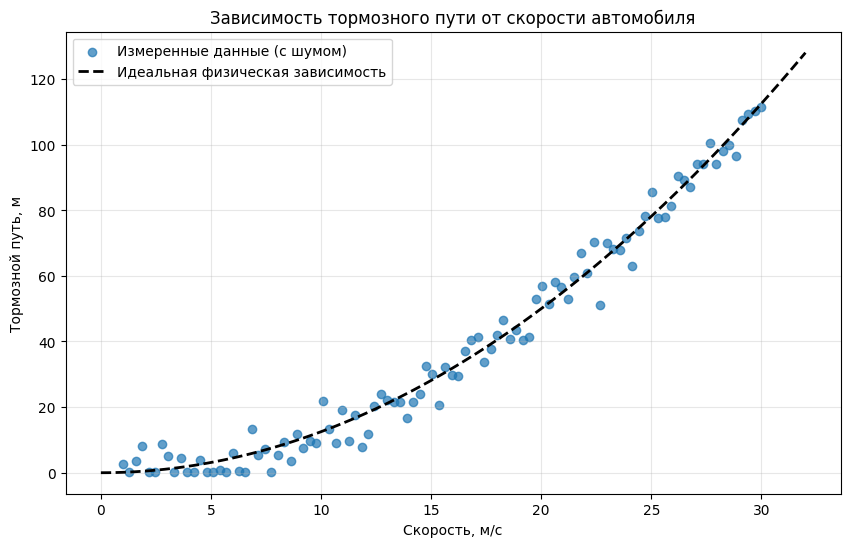

In [4]:
# Визуализация сгенерированных данных
plt.figure(figsize=(10, 6))
plt.scatter(v, s, alpha=0.7, label='Измеренные данные (с шумом)')

v_ideal = np.linspace(0, 32, 100)
s_ideal = v_ideal**2 / (2 * 4.0)
plt.plot(v_ideal, s_ideal, 'k--', linewidth=2, label='Идеальная физическая зависимость')

plt.xlabel('Скорость, м/с')
plt.ylabel('Тормозной путь, м')
plt.title('Зависимость тормозного пути от скорости автомобиля')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2: Реализация градиентного спуска

В этой части мы реализуем градиентный спуск для обучения линейной регрессии.

Напомним, что мы минимизируем функцию потерь MSE:

$$L(\boldsymbol{\theta}) = \frac{1}{2n}\sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol{\theta})^2$$

где $\boldsymbol{\theta} = (\theta_0, \theta_1)$ - параметры модели, а $\mathbf{x}_i = (1, v_i)$ - вектор признаков с фиктивным добавленным признаком из 1.

Градиент этой функции:

$$\nabla_{\boldsymbol{\theta}} L(\boldsymbol{\theta}) = \frac{1}{n} X^\top (X\boldsymbol{\theta} - y)$$

Алгоритм градиентного спуска:

$$\boldsymbol{\theta}^{(t+1)} = \boldsymbol{\theta}^{(t)} - \eta \cdot \nabla_{\boldsymbol{\theta}} L(\boldsymbol{\theta}^{(t)})$$

In [ ]:
# Добавляем фиктивный признак x₀ = 1
X = np.column_stack([np.ones(len(v)), v])  # X = [1, v]
print(f"Размерность: {X.shape}")

Размерность: (100, 2)


In [ ]:
# Реализация функций

def compute_predictions(X, theta):
    """Вычисление предсказаний: Xθ"""
    return X @ theta

def compute_loss(X, y, theta):
    """Функция потерь MSE: L(θ) = 1/(2n) * Σ(y_i - x_iθ)²"""
    n = len(y)
    errors = y - compute_predictions(X, theta)
    return (1 / (2 * n)) * np.sum(errors ** 2)

def compute_gradient(X, y, theta):
    """Градиент: ∇L(θ) = (1/n) * Xᵀ(Xθ - y)"""
    n = len(y)
    predictions = compute_predictions(X, theta)
    errors = predictions - y
    return (1 / n) * X.T @ errors

In [ ]:
# Проверим работу функций на нулевых начальных параметрах
theta_init = np.array([0.0, 0.0])
loss_init = compute_loss(X, s, theta_init)
gradient_init = compute_gradient(X, s, theta_init)

print(f"Начальные параметры: θ = {theta_init}")
print(f"Значение функция потерь до обучения: L(θ) = {loss_init:.2f}")
print(f"Начальный градиент: ∇L(θ) = {gradient_init}")

Начальные параметры: θ = [0. 0.]
Значение функция потерь до обучения: L(θ) = 1326.55
Начальный градиент: ∇L(θ) = [ -38.63597038 -875.60827099]



Реализуем алгоритм градиентного спуска:


In [ ]:
def gradient_descent(X, y, initial_theta, learning_rate=0.001, n_iterations=100):
    """Реализация градиентного спуска"""
    theta = initial_theta.copy()
    loss_history = []

    for i in range(n_iterations):
        # Вычисляем градиент
        gradient = compute_gradient(X, y, theta)

        # Обновляем параметры
        theta = theta - learning_rate * gradient

        # Сохраняем значение функции потерь
        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

In [ ]:
# Обучаем модель с шагом η
theta_optimal, losses = gradient_descent(X, s, theta_init, learning_rate=0.001, n_iterations=100)

print("\nРезультаты обучения:")
print(f"Оптимальные параметры: θ₀ = {theta_optimal[0]:.2f}, θ₁ = {theta_optimal[1]:.2f}")
print(f"Значение функции потерь после обучения: L(θ) = {losses[-1]:.2f}")
print(f"Построенная модель: s = {theta_optimal[0]:.2f} + {theta_optimal[1]:.2f}·v")


Результаты обучения:
Оптимальные параметры: θ₀ = -0.35, θ₁ = 2.83
Значение функции потерь после обучения: L(θ) = 95.21
Построенная модель: s = -0.35 + 2.83·v


### 3: Визуализация процесса обучения и результата

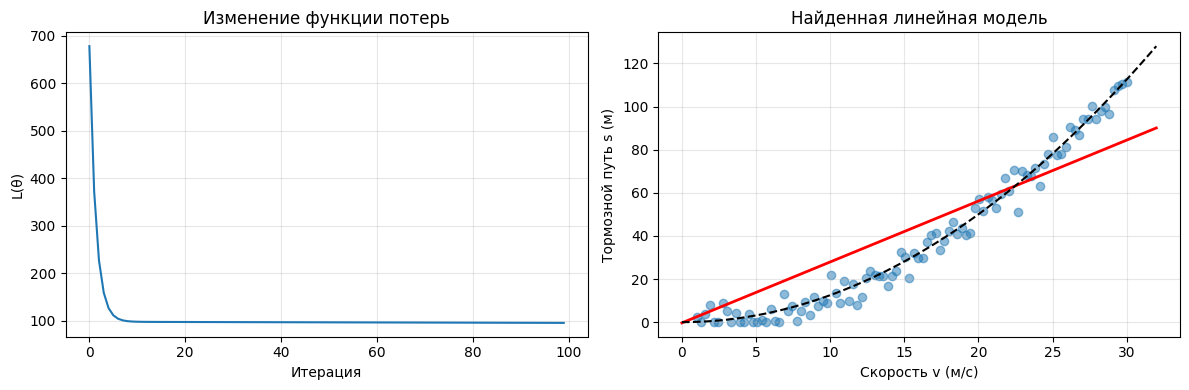

In [ ]:
# Изменение функциия потерь во время обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Итерация')
plt.ylabel('L(θ)')
plt.title('Изменение функции потерь')
plt.grid(True, alpha=0.3)

# Обученная модель на данных
plt.subplot(1, 2, 2)
plt.scatter(v, s, alpha=0.5)

# Предсказания обученной модели
v_plot = np.linspace(0, 32, 100)
X_plot = np.column_stack([np.ones(100), v_plot])
s_pred = compute_predictions(X_plot, theta_optimal)

plt.plot(v_plot, s_pred, 'red', linewidth=2)
plt.plot(v_plot, v_plot**2/(2*4.0), 'k--')

plt.xlabel('Скорость v (м/с)')
plt.ylabel('Тормозной путь s (м)')
plt.title('Найденная линейная модель')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Задание: Изучение работы градиентного спуска и улучшение модели

##  1: Исследование шага обучения
Проведите эксперименты с разными значениями шага обучения (η). Попробуйте (это примерные значения):
- Очень маленькие: 0.00001, 0.0001
- Умеренные: 0.001, 0.005  
- Слишком большие: 0.01, 0.1

Для каждого η:
1. Запустите градиентный спуск на 100 итераций (или другое число)
2. Постройте график функции потерь
3. Найдите случаи: медленная сходимость, хорошая сходимость, расходимость

##  2: Оценка качества модели
Для лучшей линейной модели вычислите метрики качества:
- MSE, MAE, MAPE, R²
- Используйте функции из sklearn.metrics

## 3: Квадратичная модель
Улучшите модель, добавив квадратичный признак:
1. Создайте признаки: [1, v, v²]
2. Обучите модель с 3 параметрами
3. Постройте кривую обучения
4. Вычислите метрики и сравните с линейной моделью
5. Сделайте выводы: какая модель лучше и почему

Используйте код из предыдущих частей, меняя только параметры и добавляя новые признаки.